In [149]:
#ДЗ 
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

Длина наиболее протяженной черной линии: 254.12


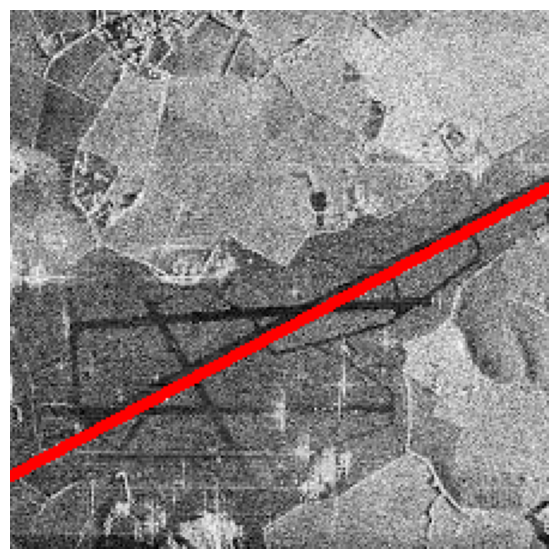

In [2]:
# 1. Поиск наиболее протяженной черной линии с помощью преобразования Хафа
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, dark = cv2.threshold(
    image_gray, 90, 255, cv2.THRESH_BINARY_INV
)

lines = cv2.HoughLinesP(
    dark,
    1,
    np.pi / 180,
    threshold=25,
    minLineLength=50,
    maxLineGap=15
)

max_length = 0
best_line = None

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]

        length = np.sqrt(
            (x2 - x1)**2 + (y2 - y1)**2
        )

        angle = np.degrees(
            np.arctan2(y2 - y1, x2 - x1)
        )

        if -30 <= angle <= -25:
            if length > max_length:
                max_length = length
                best_line = (x1, y1, x2, y2)

result = image.copy()

if best_line is not None:
    x1, y1, x2, y2 = best_line

    cv2.line(
        result,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        3
    )

print(
    "Длина наиболее протяженной черной линии:",
    round(max_length, 2)
)

plt.figure(figsize=(7, 7))
plt.imshow(
    cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
)
plt.axis('off')
plt.show()

Порог Оцу: 129.0


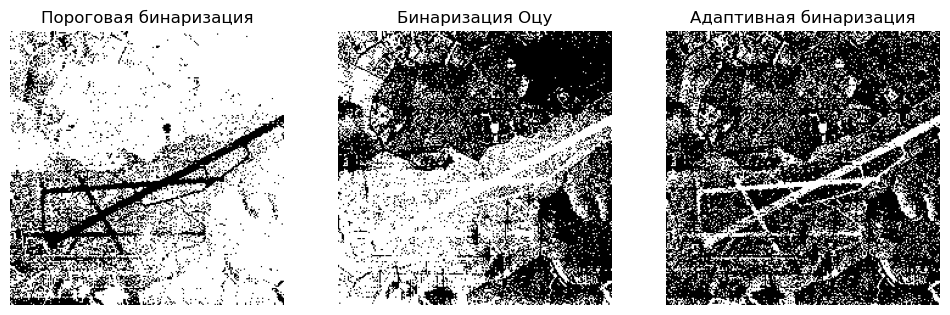

In [4]:
# 2. Исследование методов бинаризации

image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

T = 90
bin_img = copy.deepcopy(image_gray)

bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

T_otsu, otsu = cv2.threshold(
    image_gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

adaptive = cv2.adaptiveThreshold(
    image_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    71, 21
)

print("Порог Оцу:", T_otsu)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(bin_img, cmap="gray")
plt.title("Пороговая бинаризация")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(otsu, cmap="gray")
plt.title("Бинаризация Оцу")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(adaptive, cmap="gray")
plt.title("Адаптивная бинаризация")
plt.axis("off")

plt.show()

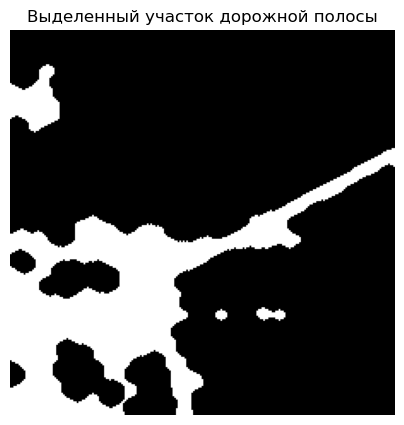

In [9]:
# Выделение дорожного участка

road = otsu.copy()

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

road = cv2.morphologyEx(road, cv2.MORPH_OPEN, kernel)
road = cv2.morphologyEx(road, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.imshow(road, cmap="gray")
plt.title("Выделенный участок дорожной полосы")
plt.axis("off")

plt.show()